In [7]:
import pandas as pd
import numpy as np

In [28]:
playlist = pd.read_csv("phase5_model_development/dataset/playlist_with_segment.csv")

In [29]:
playlist['sentiment_centroid'] = playlist['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))
playlist['genre_centroid'] = playlist['genre_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

In [30]:
playlist_sentiment_df = playlist['sentiment_centroid'].apply(pd.Series)

# Rename columns to match the number of sentiment components
playlist_sentiment_df.columns = ["joy", "calm", "sadness", "fear", "energizing", "dreamy"]

# Merge back with the original DataFrame (optional)
playlist = pd.concat([playlist.drop(columns=['sentiment_centroid']), playlist_sentiment_df], axis=1)

In [31]:
playlist_genre_df = playlist['genre_centroid'].apply(pd.Series)

# Rename columns to match the number of sentiment components
playlist_genre_df.columns = ["Instrumental / Ambient Sounds", "Soft Acoustic / Classical", "Orchestral / Soundtrack", "Mid-tempo Pop / Indie", "Upbeat Electronic / Dance", "Slow & Melancholic (Sad Songs)", "Experimental / Jazz Fusion", "Lo-Fi / Chill Vibes"]

# Merge back with the original DataFrame (optional)
playlist = pd.concat([playlist.drop(columns=['genre_centroid']), playlist_genre_df], axis=1)

In [12]:
playlist

,playlist_idx,cluster,dataset_type,name,name_embeddings,num_tracks,track_idx_list,tracks_to_predict,tracks_weights_5dp,num_edits,...,energizing,dreamy,Instrumental / Ambient Sounds,Soft Acoustic / Classical,Orchestral / Soundtrack,Mid-tempo Pop / Indie,Upbeat Electronic / Dance,Slow & Melancholic (Sad Songs),Experimental / Jazz Fusion,Lo-Fi / Chill Vibes
0,1,1,train,fall '17,[ 1.66989997e-01 -8.01749974e-02 -2.72219986e-...,32,['3689' '207774' '194775' '135193' '218011' '3...,['218708' '242974' '165272' '9418' '221860' '2...,"[('3689', 0.00758), ('207774', 0.00758), ('194...",11,...,0.235716,0.190645,0.339394,0.060289,0.130187,0.185879,0.064306,0.066901,0.106178,0.046866
1,2,3,train,HALLOWEEN,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,10,['160375' '131195' '164629' '147280' '193891' ...,['232845' '111887' '144160' '10663' '216321' '...,"[('160375', 0.1), ('131195', 0.1), ('164629', ...",1,...,0.270555,0.255755,0.175391,0.244045,0.104636,0.236158,0.010895,0.107065,0.007359,0.114451
2,3,3,validation,90s,[-0.32666001 -0.15259001 -0.22385 0.49504 ...,52,['104436' '229428' '25968' '186871' '81592' '1...,['42986' '156208' '73950' '54114' '134077' '21...,"[('104436', 0.00321), ('229428', 0.00321), ('2...",12,...,0.279806,0.216025,0.174446,0.083760,0.239169,0.239104,0.030993,0.062901,0.066042,0.103585
3,4,0,train,Me Like,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,64,['244173' '210510' '9349' '224202' '147251' '3...,['166268' '22122' '211269' '71335' '21853' '19...,"[('244173', 0.00195), ('210510', 0.00195), ('9...",18,...,0.314236,0.234473,0.378407,0.077472,0.156780,0.081669,0.009754,0.060618,0.112403,0.122896
4,5,0,train,Latin Trap,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,73,['194410' '10513' '62267' '196463' '14164' '13...,['209088' '186942' '33032' '27612' '33426' '20...,"[('194410', 0.00556), ('10513', 0.00556), ('62...",4,...,0.310155,0.197386,0.475254,0.029123,0.077732,0.161558,0.056961,0.043874,0.071201,0.084297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18499,19995,1,train,( r e l a x ),[ 7.05714291e-03 5.35708606e-01 -2.79046565e-...,59,['76313' '158471' '130259' '235274' '3915' '34...,['20667' '215021' '93712' '98021' '14511' '100...,"[('76313', 0.00215), ('158471', 0.00215), ('13...",30,...,0.276759,0.204737,0.093107,0.348130,0.126471,0.268350,0.073805,0.043827,0.040999,0.005311
18500,19996,1,train,Playlist,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,157,['69011' '123049' '192091' '214626' '220817' '...,['147645' '172628' '240055' '34789' '191673' '...,"[('69011', 0.00014), ('123049', 0.00029), ('19...",117,...,0.240320,0.194145,0.557355,0.029494,0.088795,0.109535,0.034748,0.038896,0.071059,0.070117
18501,19997,1,test,🔥🔥🔥,[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. ...,161,['140314' '14975' '99481' '234471' '72522' '18...,['1713' '218750' '204173' '42649' '114706' '23...,"[('140314', 0.00018), ('14975', 0.00018), ('99...",74,...,0.260378,0.177363,0.465005,0.039477,0.089565,0.138542,0.040888,0.037123,0.105614,0.083786
18502,19998,3,train,sad times,[ 0.061155 0.620215 -0.1455825 -0.020739...,106,['82540' '34319' '119829' '244328' '232829' '1...,['168352' '115537' '230715' '208147' '33022' '...,"[('82540', 0.00035), ('34319', 0.00035), ('119...",53,...,0.277225,0.229730,0.284042,0.289435,0.071263,0.143221,0.019117,0.105590,0.032033,0.055299


In [32]:
genre_columns = [
    "Instrumental / Ambient Sounds",
    "Soft Acoustic / Classical",
    "Orchestral / Soundtrack",
    "Mid-tempo Pop / Indie",
    "Upbeat Electronic / Dance",
    "Slow & Melancholic (Sad Songs)",
    "Experimental / Jazz Fusion",
    "Lo-Fi / Chill Vibes"
]

# Compute row sums before normalization
sum_before = playlist[genre_columns].sum(axis=1)

# Normalize only the genre columns
playlist[genre_columns] = playlist[genre_columns].div(sum_before, axis=0)

# Compute row sums after normalization
sum_after = playlist[genre_columns].sum(axis=1)

# Display min and max row sums before and after normalization
print(f"Before Normalization: Min Sum = {sum_before.min()}, Max Sum = {sum_before.max()}")
print(f"After Normalization: Min Sum = {sum_after.min()}, Max Sum = {sum_after.max()}")

Before Normalization: Min Sum = 0.9999999700000001, Max Sum = 1.00000003
After Normalization: Min Sum = 0.9999999999999996, Max Sum = 1.0000000000000004


In [33]:
sentiment_columns = ["joy", "calm", "sadness", "fear", "energizing", "dreamy"]

# Compute row sums before normalization
sum_before = playlist[sentiment_columns].sum(axis=1)

# Normalize only the genre columns
playlist[sentiment_columns] = playlist[sentiment_columns].div(sum_before, axis=0)

# Compute row sums after normalization
sum_after = playlist[sentiment_columns].sum(axis=1)

# Display min and max row sums before and after normalization
print(f"Before Normalization: Min Sum = {sum_before.min()}, Max Sum = {sum_before.max()}")
print(f"After Normalization: Min Sum = {sum_after.min()}, Max Sum = {sum_after.max()}")

Before Normalization: Min Sum = 0.9999999799999999, Max Sum = 1.00000002
After Normalization: Min Sum = 0.9999999999999997, Max Sum = 1.0000000000000002


In [16]:
popularity = ["popularity_mean"]
era_cols = ['era_early_years_proportion', 'era_classic_era_proportion', 'era_golden_era_proportion', 'era_2000s_proportion', 'era_modern_era_proportion']
length_cols = ['length_short_proportion', 'length_medium_proportion', 'length_long_proportion']
sentiment_columns = ["joy", "calm", "sadness", "fear", "energizing", "dreamy"]
genre_columns = [
    "Instrumental / Ambient Sounds",
    "Soft Acoustic / Classical",
    "Orchestral / Soundtrack",
    "Mid-tempo Pop / Indie",
    "Upbeat Electronic / Dance",
    "Slow & Melancholic (Sad Songs)",
    "Experimental / Jazz Fusion",
    "Lo-Fi / Chill Vibes"
]

first = playlist.loc[0]

In [34]:
first

playlist_idx                                                                      1
cluster                                                                           1
dataset_type                                                                  train
name                                                                       fall '17
name_embeddings                   [ 1.66989997e-01 -8.01749974e-02 -2.72219986e-...
num_tracks                                                                       32
track_idx_list                    ['3689' '207774' '194775' '135193' '218011' '3...
tracks_to_predict                 ['218708' '242974' '165272' '9418' '221860' '2...
tracks_weights_5dp                [('3689', 0.00758), ('207774', 0.00758), ('194...
num_edits                                                                        11
avg_tracks_per_edit                                                             2.8
num_artists                                                                 

In [45]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


# List of genre columns to consider
genre_columns = [
    "Instrumental / Ambient Sounds",
    "Soft Acoustic / Classical",
    "Orchestral / Soundtrack",
    "Mid-tempo Pop / Indie",
    "Upbeat Electronic / Dance",
    "Slow & Melancholic (Sad Songs)",
    "Experimental / Jazz Fusion",
    "Lo-Fi / Chill Vibes"
]

# Select the first 5 rows and only the genre columns
genre_df = playlist[genre_columns].iloc[:5]

# Calculate cosine similarity between the rows
cosine_sim = cosine_similarity(genre_df)

# Convert the cosine similarity matrix into a DataFrame for better readability
cosine_sim_df = pd.DataFrame(cosine_sim, index=playlist["playlist_idx"][:5], columns=playlist["playlist_idx"][:5])

# Display the cosine similarity matrix
print(cosine_sim_df)

playlist_idx         1         2         3         4         5
playlist_idx                                                  
1             1.000000  0.779449  0.868443  0.946157  0.960032
2             0.779449  1.000000  0.859741  0.725770  0.679434
3             0.868443  0.859741  1.000000  0.805885  0.736854
4             0.946157  0.725770  0.805885  1.000000  0.946690
5             0.960032  0.679434  0.736854  0.946690  1.000000


In [46]:
genre_df

,Instrumental / Ambient Sounds,Soft Acoustic / Classical,Orchestral / Soundtrack,Mid-tempo Pop / Indie,Upbeat Electronic / Dance,Slow & Melancholic (Sad Songs),Experimental / Jazz Fusion,Lo-Fi / Chill Vibes
0,0.339394,0.060289,0.130187,0.185879,0.064306,0.066901,0.106178,0.046866
1,0.175391,0.244045,0.104636,0.236158,0.010895,0.107065,0.007359,0.114451
2,0.174446,0.083760,0.239169,0.239104,0.030993,0.062901,0.066042,0.103585
3,0.378407,0.077472,0.156780,0.081669,0.009754,0.060618,0.112403,0.122896
4,0.475254,0.029123,0.077732,0.161558,0.056961,0.043874,0.071201,0.084297


In [98]:
import numpy as np
genre_df = playlist[genre_columns]
genre_df_squared = genre_df ** 4

In [99]:
genre_df_squared.head(5)

,Instrumental / Ambient Sounds,Soft Acoustic / Classical,Orchestral / Soundtrack,Mid-tempo Pop / Indie,Upbeat Electronic / Dance,Slow & Melancholic (Sad Songs),Experimental / Jazz Fusion,Lo-Fi / Chill Vibes
0,0.013268,1.321108e-05,0.000287,0.001194,1.710077e-05,0.000020,1.270999e-04,0.000005
1,0.000946,3.547143e-03,0.000120,0.003110,1.409112e-08,0.000131,2.932831e-09,0.000172
2,0.000926,4.922161e-05,0.003272,0.003268,9.227229e-07,0.000016,1.902294e-05,0.000115
3,0.020504,3.602334e-05,0.000604,0.000044,9.053537e-09,0.000014,1.596283e-04,0.000228
4,0.051016,7.193945e-07,0.000037,0.000681,1.052679e-05,0.000004,2.570026e-05,0.000050


In [100]:
# # Select the first 5 rows and only the genre columns
# genre_df_squared = genre_df_squared[genre_columns].iloc[:5]

# # Calculate cosine similarity between the rows
# cosine_sim = cosine_similarity(genre_df_squared)

# # Convert the cosine similarity matrix into a DataFrame for better readability
# cosine_sim_df = pd.DataFrame(cosine_sim, index=playlist["playlist_idx"][:5], columns=playlist["playlist_idx"][:5])

# # Display the cosine similarity matrix
# print(cosine_sim_df)

Similarity 0.0 - 0.1: 103520
Similarity 0.1 - 0.2: 29852
Similarity 0.2 - 0.3: 20029
Similarity 0.3 - 0.4: 16407
Similarity 0.4 - 0.5: 13210
Similarity 0.5 - 0.6: 12898
Similarity 0.6 - 0.7: 16735
Similarity 0.7 - 0.8: 22957
Similarity 0.8 - 0.9: 20095
Similarity 0.9 - 1.0: 243797


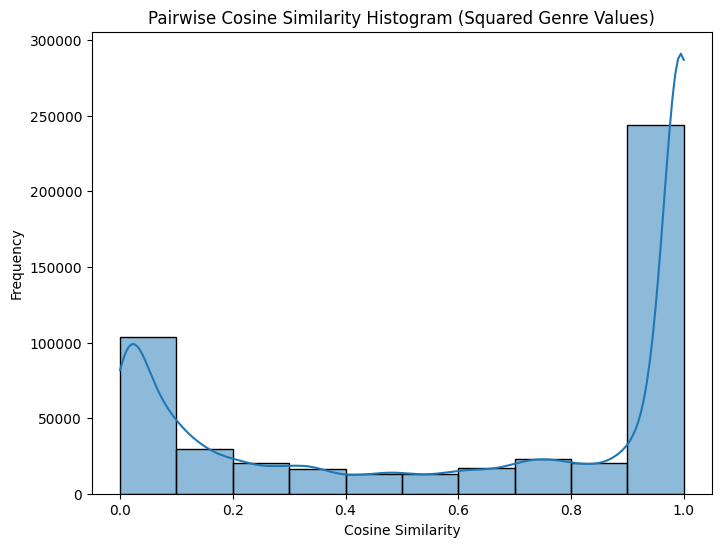

In [102]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Assuming 'genre_df_squared' is the DataFrame containing the squared genre columns.
genre_df_squared = genre_df_squared.tail(1000)

# Step 2: Calculate pairwise cosine similarity
similarity_matrix = cosine_similarity(genre_df_squared)

# Step 3: Flatten the similarity matrix and remove diagonal values (self-similarity)
similarity_values = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

# Step 4: Compute the count for each 0.1 interval
bins = np.arange(0, 1.1, 0.1)  # Bins: 0.0-0.1, 0.1-0.2, ..., 0.9-1.0
counts, _ = np.histogram(similarity_values, bins=bins)

# Print the count for each bin
for i in range(len(bins) - 1):
    print(f"Similarity {bins[i]:.1f} - {bins[i+1]:.1f}: {counts[i]}")

# Step 5: Plot histogram of the pairwise cosine similarities
plt.figure(figsize=(8, 6))
sns.histplot(similarity_values, kde=True, bins=10)
plt.title('Pairwise Cosine Similarity Histogram (Squared Genre Values)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

# Sentiment

In [125]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity


# List of genre columns to consider
sentiment_columns = ["joy", "calm", "sadness", "fear", "energizing", "dreamy"]


# Select the first 5 rows and only the genre columns
sentiment_df = playlist[sentiment_columns].iloc[:5]

# Calculate cosine similarity between the rows
cosine_sim = cosine_similarity(sentiment_df)

# Convert the cosine similarity matrix into a DataFrame for better readability
cosine_sim_df = pd.DataFrame(cosine_sim, index=playlist["playlist_idx"][:5], columns=playlist["playlist_idx"][:5])

# Display the cosine similarity matrix
print(cosine_sim_df)

playlist_idx         1         2         3         4         5
playlist_idx                                                  
1             1.000000  0.975850  0.989825  0.948126  0.977834
2             0.975850  1.000000  0.991775  0.946483  0.982698
3             0.989825  0.991775  1.000000  0.970244  0.995200
4             0.948126  0.946483  0.970244  1.000000  0.969277
5             0.977834  0.982698  0.995200  0.969277  1.000000


In [126]:
sentiment_df

,joy,calm,sadness,fear,energizing,dreamy
0,0.099262,0.100059,0.181741,0.192577,0.235716,0.190645
1,0.055716,0.041501,0.189295,0.187178,0.270555,0.255755
2,0.087370,0.067407,0.176587,0.172804,0.279806,0.216025
3,0.131787,0.094367,0.122619,0.102519,0.314237,0.234473
4,0.097755,0.045160,0.186669,0.162876,0.310155,0.197386


In [ ]:
import numpy as np
sentiment_df = playlist[sentiment_columns]
sentiment_df_squared = sentiment_df ** 4

In [128]:
# # Select the first 5 rows and only the genre columns
# sentiment_df_squared = sentiment_df_squared[sentiment_columns].iloc[5:10]

# # Calculate cosine similarity between the rows
# cosine_sim = cosine_similarity(sentiment_df_squared)

# # Convert the cosine similarity matrix into a DataFrame for better readability
# cosine_sim_df = pd.DataFrame(cosine_sim, index=playlist["playlist_idx"][:5], columns=playlist["playlist_idx"][:5])

# # Display the cosine similarity matrix
# print(cosine_sim_df)

Similarity 0.0 - 0.1: 1965
Similarity 0.1 - 0.2: 3759
Similarity 0.2 - 0.3: 3572
Similarity 0.3 - 0.4: 5436
Similarity 0.4 - 0.5: 4851
Similarity 0.5 - 0.6: 7306
Similarity 0.6 - 0.7: 7541
Similarity 0.7 - 0.8: 11551
Similarity 0.8 - 0.9: 30437
Similarity 0.9 - 1.0: 423081


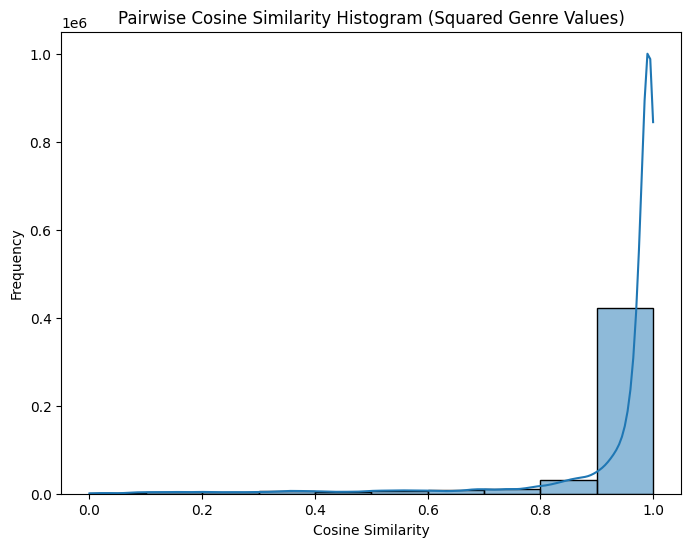

In [132]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

# Assuming 'genre_df_squared' is the DataFrame containing the squared genre columns.
sentiment_df_squared = sentiment_df_squared.head(1000)

# Step 2: Calculate pairwise cosine similarity
similarity_matrix = cosine_similarity(sentiment_df_squared)

# Step 3: Flatten the similarity matrix and remove diagonal values (self-similarity)
similarity_values = similarity_matrix[np.triu_indices_from(similarity_matrix, k=1)]

# Step 4: Compute the count for each 0.1 interval
bins = np.arange(0, 1.1, 0.1)  # Bins: 0.0-0.1, 0.1-0.2, ..., 0.9-1.0
counts, _ = np.histogram(similarity_values, bins=bins)

# Print the count for each bin
for i in range(len(bins) - 1):
    print(f"Similarity {bins[i]:.1f} - {bins[i+1]:.1f}: {counts[i]}")

# Step 5: Plot histogram of the pairwise cosine similarities
plt.figure(figsize=(8, 6))
sns.histplot(similarity_values, kde=True, bins=10)
plt.title('Pairwise Cosine Similarity Histogram (Squared Genre Values)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()